# 04d — E2.1 FaceForensics++ Internal Evaluation

**Experiment:** E2.1 — Fully fine-tuned ImageNet-pretrained EfficientNet-B0  
**Evaluation dataset:** Untouched FaceForensics++ full-frame test split

This notebook performs evaluation only. It loads `efficientnet_b0_finetuned.pth` and never trains or saves model weights.


## Evaluation protocol

- Keep the full-frame test data, EfficientNet transform, architecture, threshold and metrics identical to E2 evaluation.
- Rebuild the two-class model with `weights=None`, then strictly load the complete E2.1 checkpoint.
- Keep the fake decision threshold fixed at 0.5 with no test-set tuning.
- Report frame- and video-level accuracy, macro precision/recall/F1, fake recall, ROC-AUC, class-wise metrics and confusion matrices.
- Calculate each video probability as the mean fake probability over its ten frames.


## 1. Evaluation control


In [2]:
RUN_EVALUATION = True

DECISION_THRESHOLD = 0.5
BATCH_SIZE = 32
NUM_WORKERS = 2

# The test set must never be used to optimize this threshold.
assert DECISION_THRESHOLD == 0.5
print("E2.1 evaluation enabled:", RUN_EVALUATION)

E2.1 evaluation enabled: True


## 2. Imports, paths and device


In [3]:
from google.colab import drive
drive.mount("/content/drive")

import os
import json
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from torchvision import datasets
from torchvision.models import EfficientNet_B0_Weights, efficientnet_b0
from torch.utils.data import DataLoader
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
)

BASE_PATH = "/content/drive/MyDrive/deepfake_project"
TEST_DIR = os.path.join(BASE_PATH, "dataset", "test")
SPLIT_MANIFEST_PATH = os.path.join(
    BASE_PATH,
    "ffpp_video_split_manifest.json",
)
CHECKPOINT_PATH = os.path.join(
    BASE_PATH,
    "saved_models",
    "efficientnet_b0_finetuned.pth",
)
RESULTS_PATH = os.path.join(
    BASE_PATH,
    "results",
    "e21_ffpp_evaluation.json",
)
CONFUSION_PLOT_PATH = os.path.join(
    BASE_PATH,
    "plots",
    "e21_ffpp_confusion_matrix.png",
)
ROC_PLOT_PATH = os.path.join(
    BASE_PATH,
    "plots",
    "e21_ffpp_roc_curve.png",
)
VIDEO_CONFUSION_PLOT_PATH = os.path.join(
    BASE_PATH,
    "plots",
    "e21_ffpp_video_confusion_matrix.png",
)
VIDEO_ROC_PLOT_PATH = os.path.join(
    BASE_PATH,
    "plots",
    "e21_ffpp_video_roc_curve.png",
)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)
print("Test data:", TEST_DIR)
print("Checkpoint:", CHECKPOINT_PATH)
print("Split manifest:", SPLIT_MANIFEST_PATH)

Mounted at /content/drive
Device: cpu
Test data: /content/drive/MyDrive/deepfake_project/dataset/test
Checkpoint: /content/drive/MyDrive/deepfake_project/saved_models/efficientnet_b0_finetuned.pth
Split manifest: /content/drive/MyDrive/deepfake_project/ffpp_video_split_manifest.json


## 3. Validate E2.1 preprocessing and the clean full-frame test split


In [4]:
weights = EfficientNet_B0_Weights.DEFAULT
e2_transform = weights.transforms()

assert os.path.isdir(TEST_DIR), f'Test folder not found: {TEST_DIR}'

test_dataset = datasets.ImageFolder(
    TEST_DIR,
    transform=e2_transform,
)
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

EXPECTED_CLASS_MAPPING = {"fake": 0, "real": 1}
if test_dataset.class_to_idx != EXPECTED_CLASS_MAPPING:
    raise ValueError(
        f"Unexpected test class mapping: {test_dataset.class_to_idx}"
    )

class_counts = {
    class_name: sum(label == class_index for label in test_dataset.targets)
    for class_name, class_index in test_dataset.class_to_idx.items()
}
if class_counts != {"fake": 300, "real": 300}:
    raise RuntimeError(f"Unexpected test class counts: {class_counts}")


def recover_video_ids(dataset):
    video_ids = set()
    for image_path, _ in dataset.samples:
        stem = os.path.splitext(os.path.basename(image_path))[0]
        if "_frame_" not in stem:
            raise ValueError(f"Cannot recover source-video id from: {image_path}")
        video_ids.add(stem.rsplit("_frame_", 1)[0])
    return video_ids


if not os.path.isfile(SPLIT_MANIFEST_PATH):
    raise FileNotFoundError(
        f"Video-level split manifest not found: {SPLIT_MANIFEST_PATH}"
    )

with open(SPLIT_MANIFEST_PATH, "r", encoding="utf-8") as manifest_file:
    split_manifest = json.load(manifest_file)

ordered_frame_video_ids = [
    os.path.splitext(os.path.basename(image_path))[0].rsplit("_frame_", 1)[0]
    for image_path, _ in test_dataset.samples
]
actual_test_video_ids = set(ordered_frame_video_ids)
expected_test_video_ids = {
    os.path.splitext(video_name)[0]
    for class_splits in split_manifest["classes"].values()
    for video_name in class_splits["test"]
}
if actual_test_video_ids != expected_test_video_ids:
    missing = sorted(expected_test_video_ids - actual_test_video_ids)[:5]
    unexpected = sorted(actual_test_video_ids - expected_test_video_ids)[:5]
    raise RuntimeError(
        "Test frames do not match the saved video split manifest. "
        f"Missing examples: {missing}; unexpected examples: {unexpected}"
    )

for class_name, class_splits in split_manifest["classes"].items():
    split_ids = {
        split: {os.path.splitext(name)[0] for name in names}
        for split, names in class_splits.items()
    }
    if (
        split_ids["train"] & split_ids["val"]
        or split_ids["train"] & split_ids["test"]
        or split_ids["val"] & split_ids["test"]
    ):
        raise RuntimeError(
            f"Source-video overlap detected in manifest for class {class_name}"
        )

REAL_INDEX = test_dataset.class_to_idx["real"]
FAKE_INDEX = test_dataset.class_to_idx["fake"]

print("Class mapping:", test_dataset.class_to_idx)
print("Class counts:", class_counts)
print("Images:", len(test_dataset))
print("Source videos:", len(actual_test_video_ids))
print("PASS: test data matches the clean video-level manifest.")
print("Real output index:", REAL_INDEX)
print("Fake output index:", FAKE_INDEX)

Class mapping: {'fake': 0, 'real': 1}
Class counts: {'fake': 300, 'real': 300}
Images: 600
Source videos: 60
PASS: test data matches the clean video-level manifest.
Real output index: 1
Fake output index: 0


## 4. Rebuild E2.1 and load its checkpoint


In [5]:
assert os.path.isfile(CHECKPOINT_PATH), (
    f"E2.1 checkpoint not found: {CHECKPOINT_PATH}"
)

model = efficientnet_b0(weights=None)
model.classifier[1] = nn.Linear(model.classifier[1].in_features, 2)
model = model.to(DEVICE)

checkpoint = torch.load(
    CHECKPOINT_PATH,
    map_location=DEVICE,
    weights_only=False,
)
if isinstance(checkpoint, dict) and "model_state_dict" in checkpoint:
    state_dict = checkpoint["model_state_dict"]
elif isinstance(checkpoint, dict) and "state_dict" in checkpoint:
    state_dict = checkpoint["state_dict"]
else:
    state_dict = checkpoint

state_dict = {
    key.removeprefix("module."): value
    for key, value in state_dict.items()
}
model.load_state_dict(state_dict, strict=True)
model.eval()
print("E2.1 checkpoint loaded successfully.")


E2.1 checkpoint loaded successfully.


## 5. Run frame-level inference and retain source-video identities


In [6]:
if RUN_EVALUATION:
    all_labels = []
    all_predictions = []
    all_fake_probabilities = []
    all_video_ids = []
    frame_offset = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(DEVICE)
            logits = model(images)
            probabilities = torch.softmax(logits, dim=1)

            fake_probabilities = probabilities[:, FAKE_INDEX]
            predictions = torch.where(
                fake_probabilities >= DECISION_THRESHOLD,
                torch.full_like(fake_probabilities, FAKE_INDEX, dtype=torch.long),
                torch.full_like(fake_probabilities, REAL_INDEX, dtype=torch.long),
            )

            batch_size_actual = labels.size(0)
            all_video_ids.extend(
                ordered_frame_video_ids[
                    frame_offset:frame_offset + batch_size_actual
                ]
            )
            frame_offset += batch_size_actual

            all_labels.extend(labels.numpy().tolist())
            all_predictions.extend(predictions.cpu().numpy().tolist())
            all_fake_probabilities.extend(
                fake_probabilities.cpu().numpy().tolist()
            )

    if frame_offset != len(test_dataset):
        raise RuntimeError(
            f"Inference covered {frame_offset} frames, expected {len(test_dataset)}."
        )
    print("Frames evaluated:", len(all_labels))
else:
    print("Evaluation skipped safely.")
    print("Set RUN_EVALUATION = True to evaluate the existing E2.1 checkpoint.")

Frames evaluated: 600


## 6. Calculate, display and save frame/video metrics


E2.1 — FACEFORENSICS++ FRAME-LEVEL RESULTS
Frames evaluated : 600
Accuracy         : 59.33%
Macro precision  : 59.37%
Macro recall     : 59.33%
Macro F1-score   : 59.30%
Fake recall      : 62.33%
ROC-AUC          : 0.6216

              precision    recall  f1-score   support

        real     0.5993    0.5633    0.5808       300
        fake     0.5881    0.6233    0.6052       300

    accuracy                         0.5933       600
   macro avg     0.5937    0.5933    0.5930       600
weighted avg     0.5937    0.5933    0.5930       600

Confusion matrix [real, fake]:
[[169 131]
 [113 187]]

E2.1 — FACEFORENSICS++ VIDEO-LEVEL RESULTS
Videos evaluated : 60
Accuracy         : 61.67%
Macro precision  : 61.68%
Macro recall     : 61.67%
Macro F1-score   : 61.66%
Fake recall      : 63.33%
ROC-AUC          : 0.6200

              precision    recall  f1-score   support

        real     0.6207    0.6000    0.6102        30
        fake     0.6129    0.6333    0.6230        30

    accur

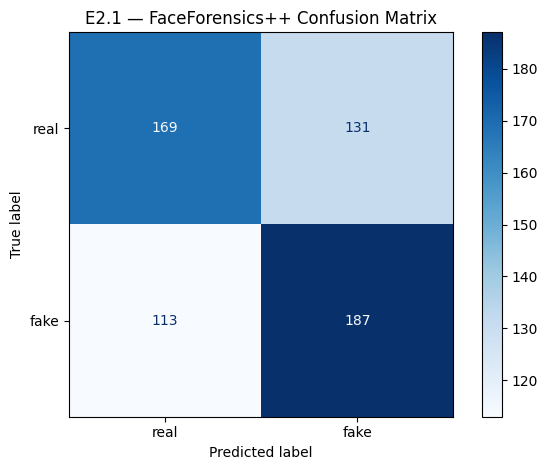

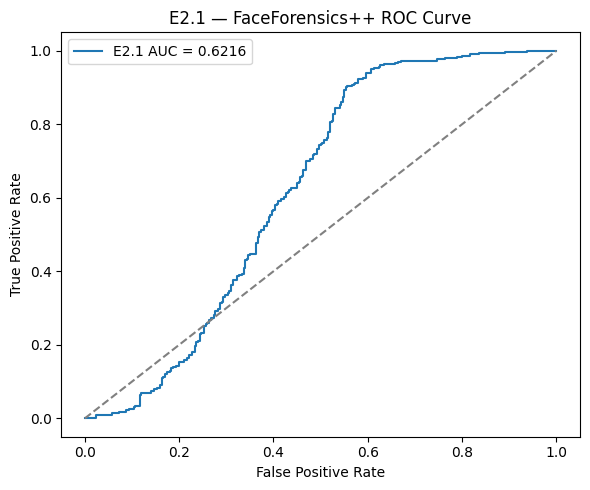

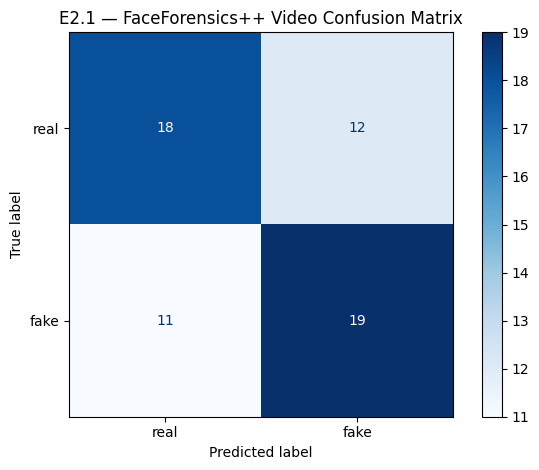

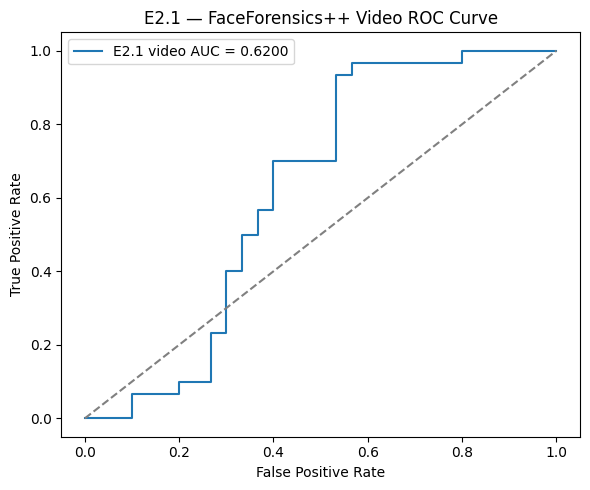

Results saved to: /content/drive/MyDrive/deepfake_project/results/e21_ffpp_evaluation.json
Confusion matrix saved to: /content/drive/MyDrive/deepfake_project/plots/e21_ffpp_confusion_matrix.png
ROC curve saved to: /content/drive/MyDrive/deepfake_project/plots/e21_ffpp_roc_curve.png
Video confusion matrix saved to: /content/drive/MyDrive/deepfake_project/plots/e21_ffpp_video_confusion_matrix.png
Video ROC curve saved to: /content/drive/MyDrive/deepfake_project/plots/e21_ffpp_video_roc_curve.png


In [7]:
if RUN_EVALUATION:
    binary_fake_labels = (
        np.asarray(all_labels) == FAKE_INDEX
    ).astype(int)

    accuracy = accuracy_score(all_labels, all_predictions)
    macro_precision = precision_score(
        all_labels,
        all_predictions,
        average="macro",
        zero_division=0,
    )
    macro_recall = recall_score(
        all_labels,
        all_predictions,
        average="macro",
        zero_division=0,
    )
    macro_f1 = f1_score(
        all_labels,
        all_predictions,
        average="macro",
        zero_division=0,
    )
    fake_recall = recall_score(
        all_labels,
        all_predictions,
        labels=[FAKE_INDEX],
        average="macro",
        zero_division=0,
    )
    roc_auc = roc_auc_score(
        binary_fake_labels,
        all_fake_probabilities,
    )

    video_records = {}
    for video_id, label, fake_probability in zip(
        all_video_ids,
        all_labels,
        all_fake_probabilities,
    ):
        record = video_records.setdefault(
            video_id,
            {"label": label, "fake_probabilities": []},
        )
        if record["label"] != label:
            raise RuntimeError(
                f"Inconsistent frame labels for source video {video_id}"
            )
        record["fake_probabilities"].append(fake_probability)

    video_ids = sorted(video_records)
    video_labels = [video_records[v]["label"] for v in video_ids]
    video_fake_probabilities = [
        float(np.mean(video_records[v]["fake_probabilities"]))
        for v in video_ids
    ]
    video_predictions = [
        FAKE_INDEX if probability >= DECISION_THRESHOLD else REAL_INDEX
        for probability in video_fake_probabilities
    ]
    binary_video_fake_labels = (
        np.asarray(video_labels) == FAKE_INDEX
    ).astype(int)

    video_accuracy = accuracy_score(video_labels, video_predictions)
    video_macro_precision = precision_score(
        video_labels, video_predictions, average="macro", zero_division=0
    )
    video_macro_recall = recall_score(
        video_labels, video_predictions, average="macro", zero_division=0
    )
    video_macro_f1 = f1_score(
        video_labels, video_predictions, average="macro", zero_division=0
    )
    video_fake_recall = recall_score(
        video_labels,
        video_predictions,
        labels=[FAKE_INDEX],
        average="macro",
        zero_division=0,
    )
    video_roc_auc = roc_auc_score(
        binary_video_fake_labels, video_fake_probabilities
    )

    ordered_labels = [REAL_INDEX, FAKE_INDEX]
    ordered_names = ["real", "fake"]
    matrix = confusion_matrix(
        all_labels,
        all_predictions,
        labels=ordered_labels,
    )
    video_matrix = confusion_matrix(
        video_labels, video_predictions, labels=ordered_labels
    )
    video_report = classification_report(
        video_labels,
        video_predictions,
        labels=ordered_labels,
        target_names=ordered_names,
        digits=4,
        zero_division=0,
        output_dict=True,
    )
    report = classification_report(
        all_labels,
        all_predictions,
        labels=ordered_labels,
        target_names=ordered_names,
        digits=4,
        zero_division=0,
        output_dict=True,
    )

    print("=" * 65)
    print("E2.1 — FACEFORENSICS++ FRAME-LEVEL RESULTS")
    print("=" * 65)
    print(f"Frames evaluated : {len(all_labels)}")
    print(f"Accuracy         : {accuracy:.2%}")
    print(f"Macro precision  : {macro_precision:.2%}")
    print(f"Macro recall     : {macro_recall:.2%}")
    print(f"Macro F1-score   : {macro_f1:.2%}")
    print(f"Fake recall      : {fake_recall:.2%}")
    print(f"ROC-AUC          : {roc_auc:.4f}")
    print()
    print(classification_report(
        all_labels,
        all_predictions,
        labels=ordered_labels,
        target_names=ordered_names,
        digits=4,
        zero_division=0,
    ))
    print("Confusion matrix [real, fake]:")
    print(matrix)

    print()
    print("=" * 65)
    print("E2.1 — FACEFORENSICS++ VIDEO-LEVEL RESULTS")
    print("=" * 65)
    print(f"Videos evaluated : {len(video_labels)}")
    print(f"Accuracy         : {video_accuracy:.2%}")
    print(f"Macro precision  : {video_macro_precision:.2%}")
    print(f"Macro recall     : {video_macro_recall:.2%}")
    print(f"Macro F1-score   : {video_macro_f1:.2%}")
    print(f"Fake recall      : {video_fake_recall:.2%}")
    print(f"ROC-AUC          : {video_roc_auc:.4f}")
    print()
    print(classification_report(
        video_labels,
        video_predictions,
        labels=ordered_labels,
        target_names=ordered_names,
        digits=4,
        zero_division=0,
    ))
    print("Confusion matrix [real, fake]:")
    print(video_matrix)

    results = {
        "experiment": "E2.1",
        "evaluation_dataset": "FaceForensics++ test split",
        "evaluation_level": "frame_and_video",
        "checkpoint": CHECKPOINT_PATH,
        "preprocessing": (
            "EfficientNet_B0_Weights.DEFAULT.transforms()"
        ),
        "class_to_idx": test_dataset.class_to_idx,
        "fake_output_index": FAKE_INDEX,
        "decision_threshold": DECISION_THRESHOLD,
        "frames_evaluated": len(all_labels),
        "source_videos_evaluated": len(actual_test_video_ids),
        "split_manifest_path": SPLIT_MANIFEST_PATH,
        "accuracy": accuracy,
        "macro_precision": macro_precision,
        "macro_recall": macro_recall,
        "macro_f1": macro_f1,
        "fake_recall": fake_recall,
        "roc_auc": roc_auc,
        "confusion_matrix_order": ordered_names,
        "confusion_matrix": matrix.tolist(),
        "classification_report": report,
        "video_level": {
            "aggregation": "mean fake probability across frames",
            "videos_evaluated": len(video_labels),
            "accuracy": video_accuracy,
            "macro_precision": video_macro_precision,
            "macro_recall": video_macro_recall,
            "macro_f1": video_macro_f1,
            "fake_recall": video_fake_recall,
            "roc_auc": video_roc_auc,
            "confusion_matrix_order": ordered_names,
            "confusion_matrix": video_matrix.tolist(),
            "classification_report": video_report,
        },
    }

    os.makedirs(os.path.dirname(RESULTS_PATH), exist_ok=True)
    os.makedirs(os.path.dirname(CONFUSION_PLOT_PATH), exist_ok=True)

    with open(RESULTS_PATH, "w") as results_file:
        json.dump(results, results_file, indent=4)

    display = ConfusionMatrixDisplay(
        confusion_matrix=matrix,
        display_labels=ordered_names,
    )
    display.plot(cmap="Blues", values_format="d")
    plt.title("E2.1 — FaceForensics++ Confusion Matrix")
    plt.tight_layout()
    plt.savefig(CONFUSION_PLOT_PATH, dpi=200)
    plt.show()

    false_positive_rate, true_positive_rate, _ = roc_curve(
        binary_fake_labels,
        all_fake_probabilities,
    )
    plt.figure(figsize=(6, 5))
    plt.plot(
        false_positive_rate,
        true_positive_rate,
        label=f"E2.1 AUC = {roc_auc:.4f}",
    )
    plt.plot([0, 1], [0, 1], "--", color="grey")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("E2.1 — FaceForensics++ ROC Curve")
    plt.legend()
    plt.tight_layout()
    plt.savefig(ROC_PLOT_PATH, dpi=200)
    plt.show()

    video_display = ConfusionMatrixDisplay(
        confusion_matrix=video_matrix,
        display_labels=ordered_names,
    )
    video_display.plot(cmap="Blues", values_format="d")
    plt.title("E2.1 — FaceForensics++ Video Confusion Matrix")
    plt.tight_layout()
    plt.savefig(VIDEO_CONFUSION_PLOT_PATH, dpi=200)
    plt.show()

    video_fpr, video_tpr, _ = roc_curve(
        binary_video_fake_labels, video_fake_probabilities
    )
    plt.figure(figsize=(6, 5))
    plt.plot(video_fpr, video_tpr, label=f"E2.1 video AUC = {video_roc_auc:.4f}")
    plt.plot([0, 1], [0, 1], "--", color="grey")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("E2.1 — FaceForensics++ Video ROC Curve")
    plt.legend()
    plt.tight_layout()
    plt.savefig(VIDEO_ROC_PLOT_PATH, dpi=200)
    plt.show()

    print("Results saved to:", RESULTS_PATH)
    print("Confusion matrix saved to:", CONFUSION_PLOT_PATH)
    print("ROC curve saved to:", ROC_PLOT_PATH)
    print("Video confusion matrix saved to:", VIDEO_CONFUSION_PLOT_PATH)
    print("Video ROC curve saved to:", VIDEO_ROC_PLOT_PATH)

## Interpretation boundary

Compare E2.1 directly with E2 using both frame- and video-level results. Because E2.1 also uses a lower learning rate, weight decay and a longer epoch budget, interpret any change as the effect of the complete full-fine-tuning regimen rather than unfreezing alone. These internal FF++ results do not establish cross-dataset generalisation.
